In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target
# df = pd.DataFrame(X_class)
# df

In [5]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [6]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [7]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [8]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [9]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [10]:
# Create SVM classifier
svm = SVC(random_state=42)

In [11]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [12]:
# Start timing
start_time = time.time()


In [13]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [14]:
# End timing
grid_time = time.time() - start_time

In [15]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 6.89 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [16]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [17]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

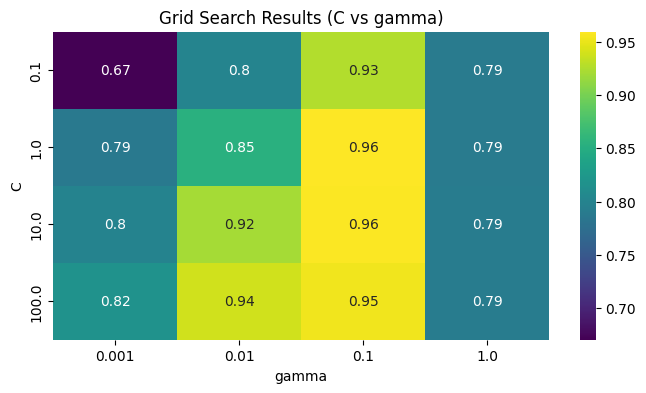

In [18]:
plt.figure(figsize=(8, 4))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [19]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [20]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [21]:
# Start timing
start_time = time.time()

In [22]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7816575cdaf0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x781657581400>,
                                        'kernel': ['rbf', 'poly']},
                   random_state=42, return_train_score=True,
                   scoring='accuracy')

In [23]:
# End timing
random_time = time.time() - start_time

In [24]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 4.37 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [25]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [26]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456            6.894876
1  Random Search       0.971429       0.964912            4.367566


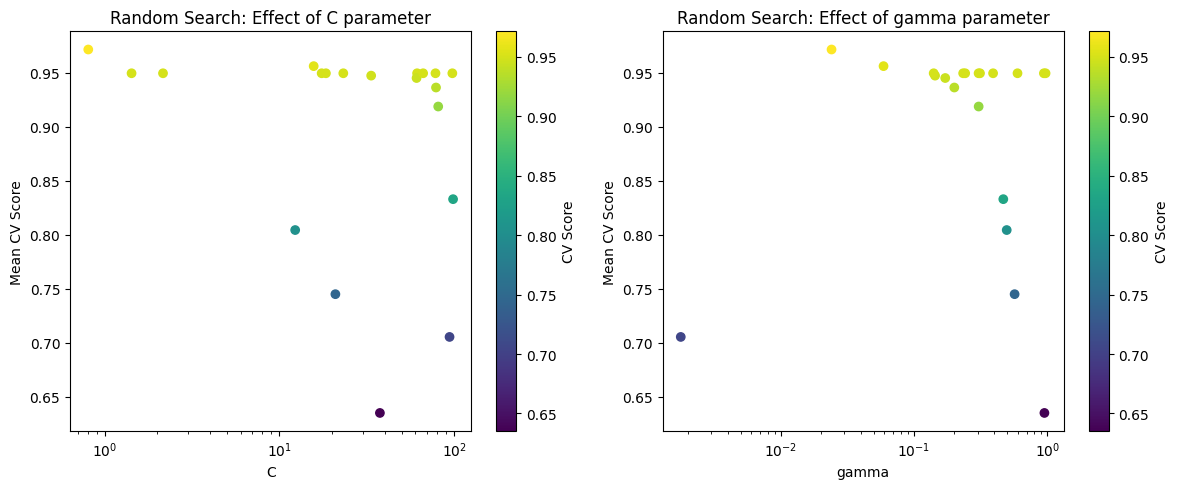

In [27]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [28]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.3 MB/s eta 0:00:00


In [29]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [30]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [31]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [32]:
# Start timing
start_time = time.time()

In [33]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

BayesSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
              random_state=42, return_train_score=True, scoring='accuracy',
              search_spaces={'C': Real(low=0.1, high=100, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('rbf', 'poly'), prior=None)})

In [34]:
# End timing
bayes_time = time.time() - start_time

In [35]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 35.36 seconds
Best parameters: OrderedDict({'C': 47.479208101330435, 'gamma': 0.01504196942704713, 'kernel': 'rbf'})
Best cross-validation score: 0.9626


In [36]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [37]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            6.894876
1          Random Search       0.971429       0.964912            4.367566
2  Bayesian Optimization       0.962637       0.956140           35.362217


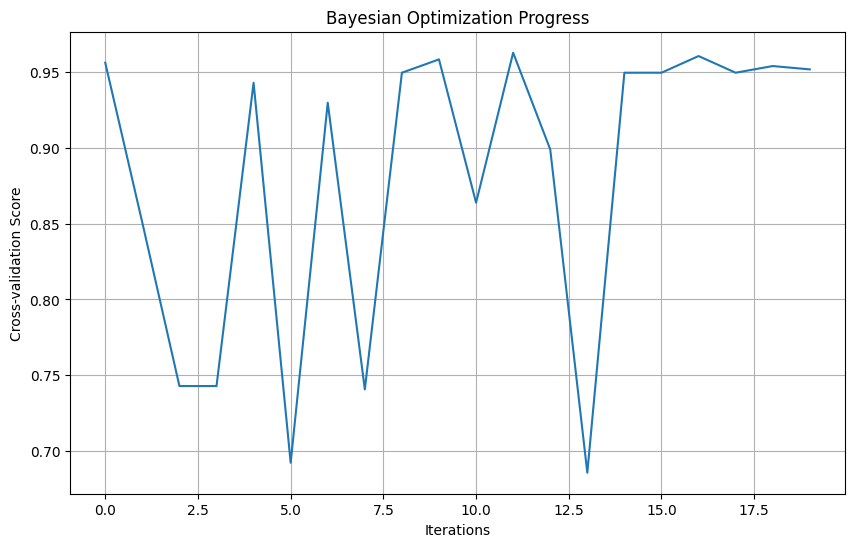

In [38]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [39]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [40]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [41]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [42]:
# Start timing
start_time = time.time()

In [43]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78165591ed20>,
                                        'regressor__max_features': ['auto',
                                                                    'sqrt',
                                                                    'log2',
                                                                    None],
                                        'regressor__min_sample...._distn_infrastructure.rv_discrete_frozen object at 0x781655832180>,
                                        'regressor__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x781655832b10>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x781655904590>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [44]:
# End timing
rf_random_time = time.time() - start_time

In [45]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 23.88 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [46]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [47]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

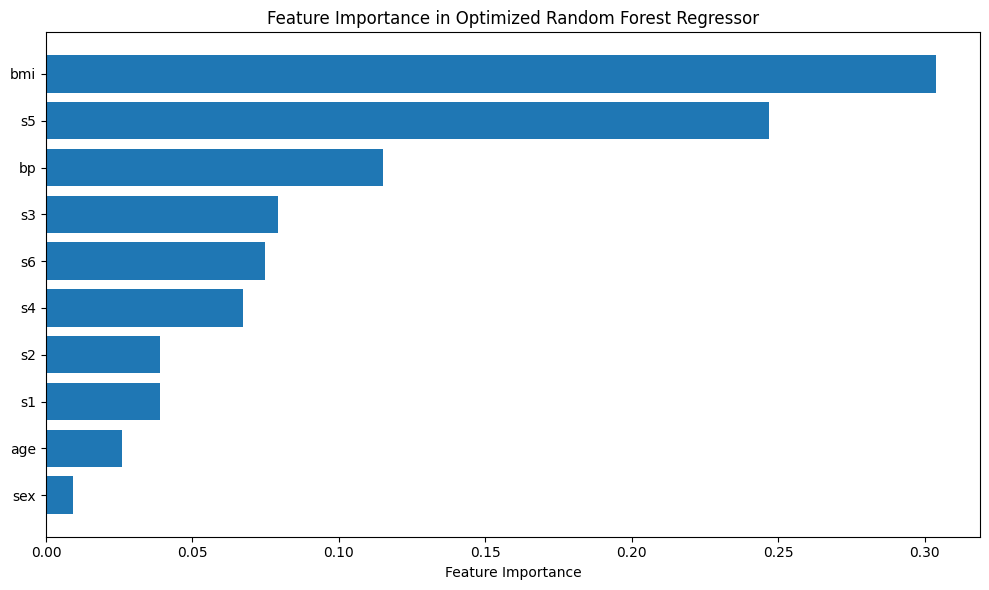

In [48]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [49]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [50]:
from sklearn.model_selection import learning_curve


In [51]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

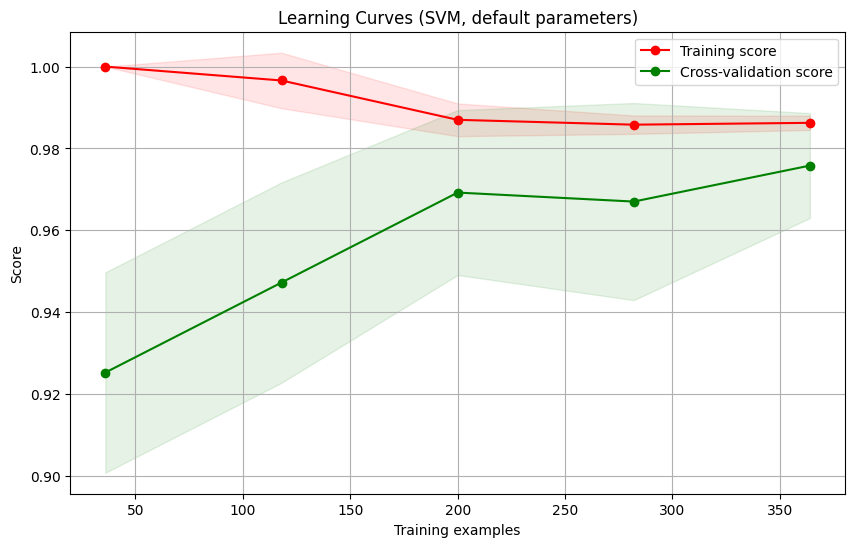

In [52]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

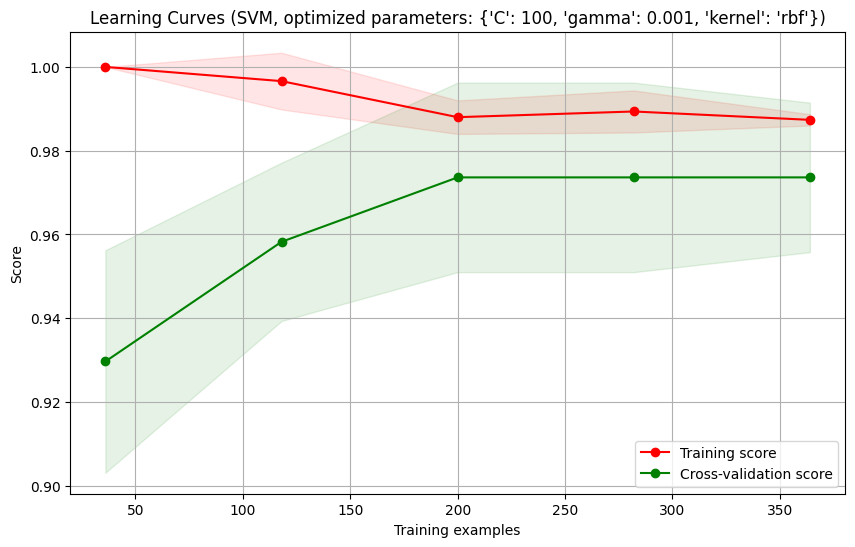

In [53]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [54]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

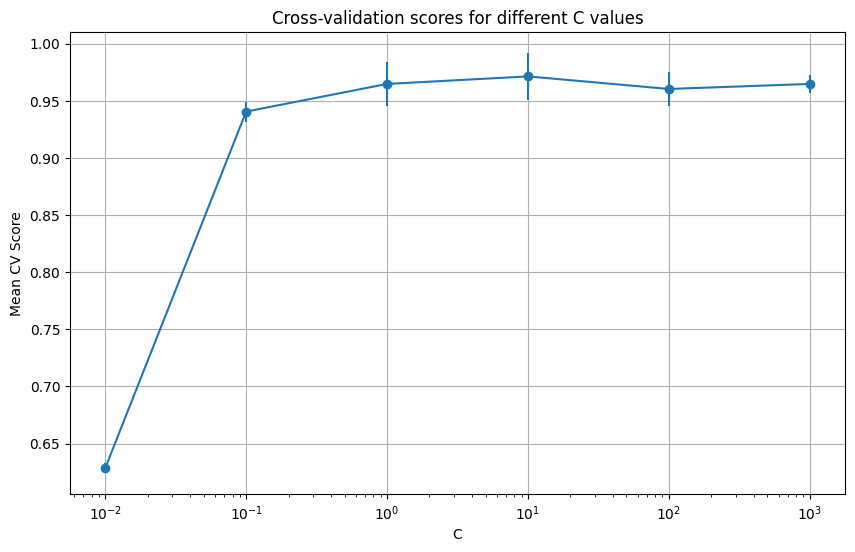

In [55]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

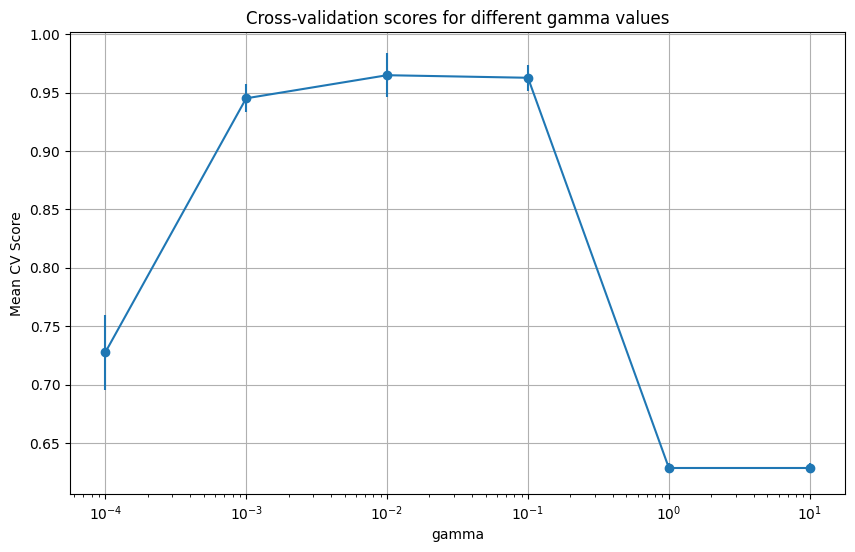

In [56]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [57]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [58]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [59]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [60]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [61]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [62]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x781655c34770>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78165580b440>,
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy')

In [63]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [64]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [65]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [66]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [67]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            6.894876
1          Random Search       0.971429       0.964912            4.367566
2  Bayesian Optimization       0.962637       0.956140           35.362217
3      Combined Approach       0.978022       0.982456                 NaN


/tmp/ipykernel_853/3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [69]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

SVC(C=47.479208101330435, gamma=0.01504196942704713, probability=True,
    random_state=42)

In [70]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [71]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

RandomForestRegressor(random_state=42)

In [72]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

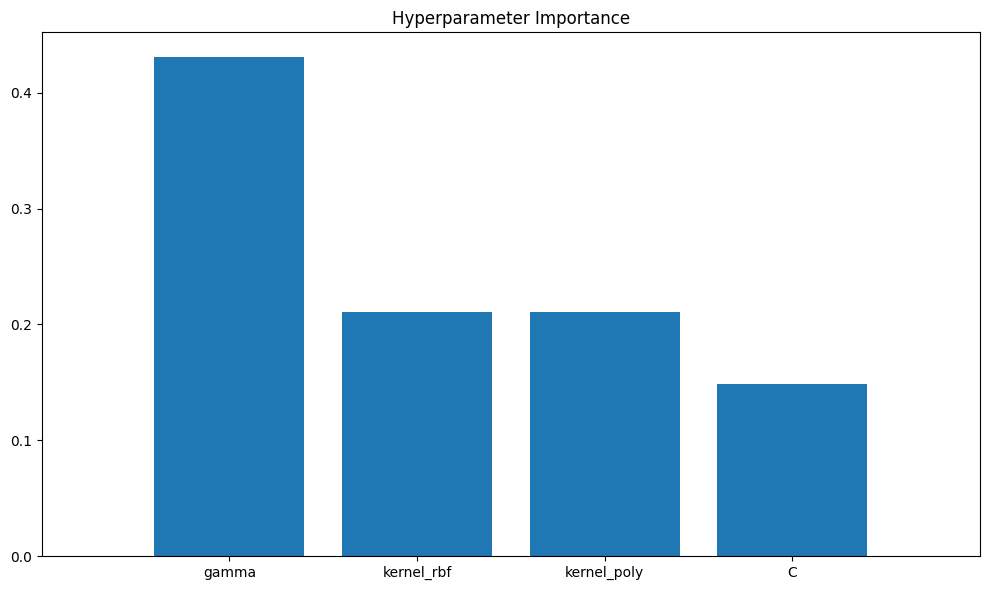

In [73]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [74]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

/tmp/ipykernel_853/149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


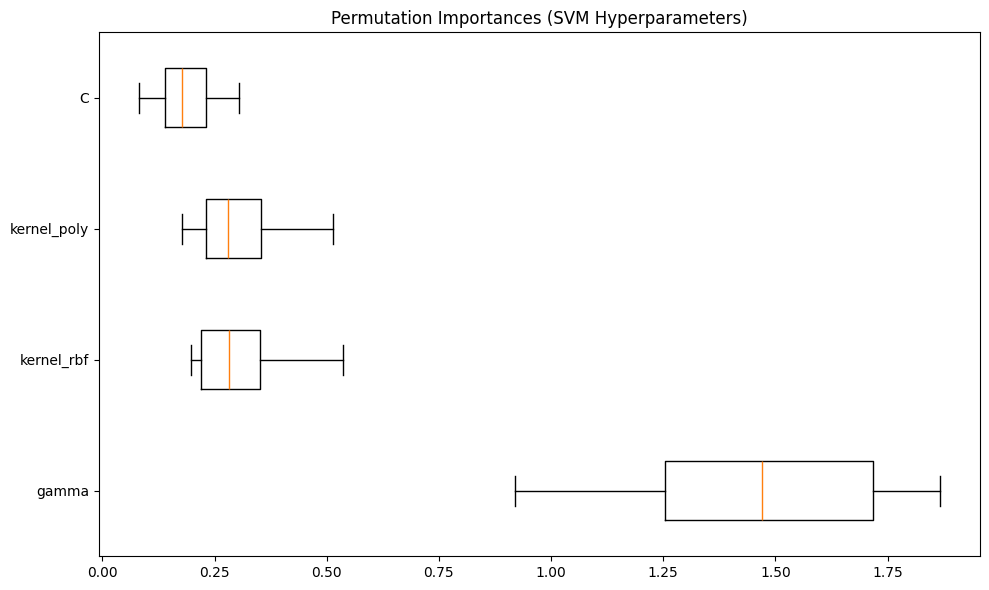

In [75]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [76]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [6]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)
# YOUR CODE HERE
X_train , X_test , y_train , y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# TODO: Standardize the features using StandardScaler
# YOUR CODE HERE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
# from sklearn.linear_model import Ridge
# from sklearn.svm import SVR
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# # TODO: Create a dictionary of baseline models with default parameters
# # Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
# # YOUR CODE HERE

# # Create baseline models
# models = {
#     "Ridge": Ridge(),
#     "SVR": SVR(),
#     "Random Forest": RandomForestRegressor(random_state=42),
#     "Gradient Boosting": GradientBoostingRegressor(random_state=42)
# }

# # TODO: Evaluate baseline models using 5-fold cross-validation
# # Calculate and print mean and std of RMSE and R² for each model
# # YOUR CODE HERE

# # Store results
# results = []

# # Check each model
# for name, model in models.items():

#     # Calculate RMSE
#     rmse_scores = np.sqrt(
#         -cross_val_score(
#             model,
#             X_train_scaled,
#             y_train,
#             cv=5,
#             scoring="neg_mean_squared_error"
#         )
#     )

#     # Calculate R²
#     r2_scores = cross_val_score(
#         model,
#         X_train_scaled,
#         y_train,
#         cv=5,
#         scoring="r2"
#     )

#     # Print Results
#     print(f"\n{name}")
#     print("Mean RMSE :", rmse_scores.mean())
#     print("Std RMSE  :", rmse_scores.std())
#     print("Mean R²   :", r2_scores.mean())
#     print("Std R²    :", r2_scores.std())

#     # Save results in a list
#     results.append([
#         name,
#         rmse_scores.mean(),
#         rmse_scores.std(),
#         r2_scores.mean(),
#         r2_scores.std()
#     ])

# # Convert list into DataFrame
# results_df = pd.DataFrame(
#     results,
#     columns=[
#         "Model",
#         "RMSE Mean",
#         "RMSE Std",
#         "R² Mean",
#         "R² Std"
#     ]
# )

# # Show DataFrame
# print(results_df)



# ---------------------------
# ---------------------------
# ---------------------------
# ---------------------------
# ---------------------------
# ---------------------------
# ---------------------------
# ---------------------------
# ---------------------------
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Create baseline models
models = dict(
    Ridge=Ridge(),
    SVR=SVR(),
    **{
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42)
    }
)

# Store evaluation results
results = []

# Evaluate every baseline model
for model_name in models:

    estimator = models[model_name]

    # Cross-validation RMSE
    neg_mse = cross_val_score(
        estimator,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    rmse_scores = np.sqrt(-neg_mse)

    # Cross-validation R²
    r2_scores = cross_val_score(
        estimator,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    )

    # Display metrics
    print(f"\n{model_name}")
    print(f"Mean RMSE : {rmse_scores.mean()}")
    print(f"Std RMSE  : {rmse_scores.std()}")
    print(f"Mean R²   : {r2_scores.mean()}")
    print(f"Std R²    : {r2_scores.std()}")

    # Save summary
    results.append({
        "Model": model_name,
        "RMSE Mean": rmse_scores.mean(),
        "RMSE Std": rmse_scores.std(),
        "R² Mean": r2_scores.mean(),
        "R² Std": r2_scores.std()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display summary table
print(results_df)


Ridge
Mean RMSE : 0.7205273313349769
Std RMSE  : 0.010280019447425959
Mean R²   : 0.6114838842658133
Std R²    : 0.006460016132780941

SVR
Mean RMSE : 0.5930564076793438
Std RMSE  : 0.010569708709117344
Mean R²   : 0.736814094424604
Std R²    : 0.00481440302783482

Random Forest
Mean RMSE : 0.5114579811554325
Std RMSE  : 0.004399490288621519
Mean R²   : 0.8041689588513355
Std R²    : 0.005324036802694173

Gradient Boosting
Mean RMSE : 0.534011953666492
Std RMSE  : 0.007126530802378533
Mean R²   : 0.7865920812042279
Std R²    : 0.0032106382274736667
               Model  RMSE Mean  RMSE Std   R² Mean    R² Std
0              Ridge   0.720527  0.010280  0.611484  0.006460
1                SVR   0.593056  0.010570  0.736814  0.004814
2      Random Forest   0.511458  0.004399  0.804169  0.005324
3  Gradient Boosting   0.534012  0.007127  0.786592  0.003211


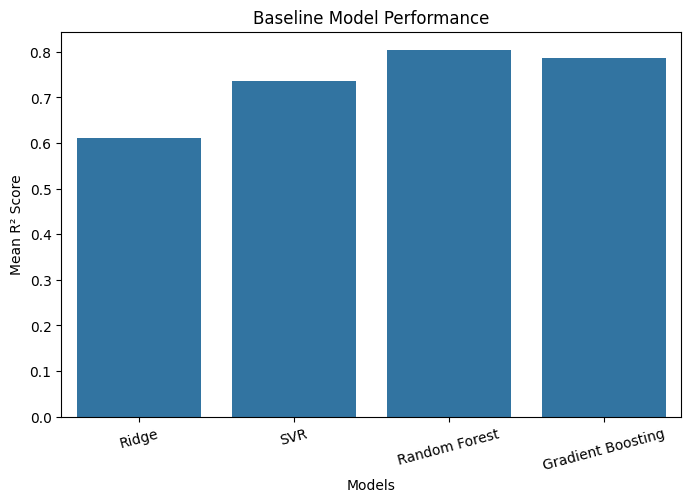

In [8]:
# TODO: Visualize baseline model performance with a bar plot
# YOUR CODE HERE
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Mean"
)

plt.title("Baseline Model Performance")
plt.xlabel("Models")
plt.ylabel("Mean R² Score")

plt.xticks(rotation=15)

plt.show()

In [ ]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
# from sklearn.model_selection import GridSearchCV

# TODO: Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
# Parameter grids for each model

# param_grids = {

#     "Ridge": {
#         "alpha": [0.1, 1, 10]
#     },

#     "SVR": {
#         "C": [1, 10],
#         "gamma": [0.01, 0.1],
#         "kernel": ["rbf"]
#     },

#     "Random Forest": {
#         "n_estimators": [50, 100],
#         "max_depth": [5, 10, None],
#         "min_samples_split": [2, 5]
#     },

#     "Gradient Boosting": {
#         "n_estimators": [50, 100],
#         "max_depth": [3, 5],
#         "learning_rate": [0.05, 0.1]
#     }
# }

# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV

# Parameter grid for each baseline model
ridge_grid = {
    "alpha": [0.1, 1, 10]
}

svr_grid = {
    "C": [1, 10],
    "gamma": [0.01, 0.1],
    "kernel": ["rbf"]
}

rf_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

gb_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

# Combine all parameter grids
param_grids = {
    "Ridge": ridge_grid,
    "SVR": svr_grid,
    "Random Forest": rf_grid,
    "Gradient Boosting": gb_grid
}


In [ ]:
# TODO: Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
# Function to perform Grid Search

# def run_grid_search(model, params, X, y):

#     start = time.time()

#     grid = GridSearchCV(
#         estimator=model,
#         param_grid=params,
#         cv=2,
#         scoring="r2",
#         n_jobs=-1
#     )

#     # Train Grid Search
#     grid.fit(X, y)

#     end = time.time()

#     return (
#         grid.best_estimator_,
#         grid.best_params_,
#         grid.best_score_,
#         end - start
#     )


# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# -------------------------------------------------
# Function to perform Grid Search
def run_grid_search(model, params, X, y):

    # Record starting time
    start_time = time.time()

    search = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="r2",
        cv=2,
        n_jobs=-1
    )

    # Fit the search object
    search.fit(X, y)

    # Compute elapsed time
    elapsed_time = time.time() - start_time

    return (
        search.best_estimator_,
        search.best_params_,
        search.best_score_,
        elapsed_time
    )

In [ ]:
# TODO: Apply grid search to all models
# YOUR CODE HERE
# grid_results = []

# for name, model in models.items():

#     best_model, best_params, best_score, total_time = run_grid_search(
#         model,
#         param_grids[name],
#         X_train_scaled,
#         y_train
#     )

#     grid_results.append([
#     name,
#     best_model,
#     best_score,
#     total_time,
#     best_params
# ])

# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# -----------------------------------------------------
# Apply Grid Search to all baseline models
grid_results = []

for model_name in models.keys():

    current_model = models[model_name]
    current_grid = param_grids[model_name]

    best_estimator, best_parameters, best_r2, elapsed_time = run_grid_search(
        current_model,
        current_grid,
        X_train_scaled,
        y_train
    )

    result = [
        model_name,
        best_estimator,
        best_r2,
        elapsed_time,
        best_parameters
    ]

    grid_results.append(result)

               Model  Best R² Score  Time (sec)  \
0              Ridge       0.555603    3.909086   
1                SVR       0.747590   74.271480   
2      Random Forest       0.788196  111.449297   
3  Gradient Boosting       0.810938   44.205589   

                                     Best Parameters  
0                                      {'alpha': 10}  
1           {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}  
2  {'max_depth': None, 'min_samples_split': 2, 'n...  
3  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...  


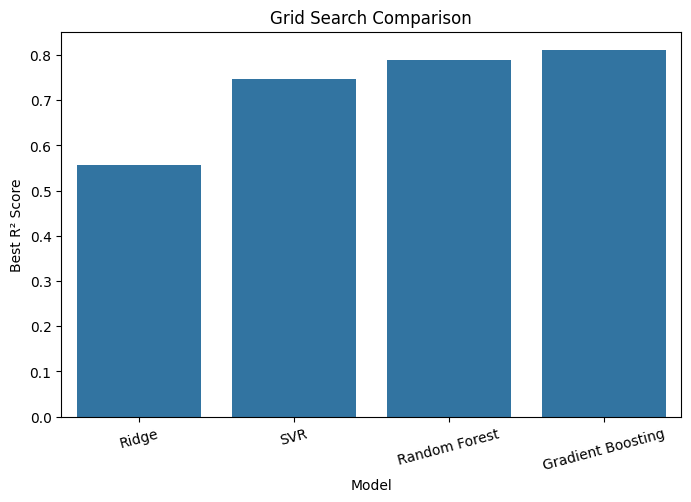

In [ ]:
# TODO: Create a comparison table or visualization of grid search results
# YOUR CODE HERE
# grid_results_df = pd.DataFrame(
#     grid_results,
#     columns=[
#         "Model",
#         "Best R² Score",
#         "Time (sec)",
#         "Best Parameters"
#     ]
# )

# print(grid_results_df)

# # Visuallisation
# plt.figure(figsize=(8,5))

# sns.barplot(
#     data=grid_results_df,
#     x="Model",
#     y="Best R² Score"
# )

# plt.title("Grid Search Comparison")
# plt.xticks(rotation=15)

# plt.show()

# -------------------------------------
# -------------------------------------
# -------------------------------------
# -------------------------------------
# -------------------------------------
# -------------------------------------
# -------------------------------------
# Create a DataFrame containing Grid Search results
column_names = [
    "Model",
    "Best R² Score",
    "Time (sec)",
    "Best Parameters"
]

grid_results_df = pd.DataFrame(grid_results, columns=column_names)

# Display the comparison table
print(grid_results_df)

# Plot comparison of best R² scores
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="Best R² Score",
    data=grid_results_df,
    ax=ax
)

ax.set_title("Grid Search Comparison")
ax.tick_params(axis="x", labelrotation=15)

plt.show()

In [ ]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint

# TODO: Define parameter distributions for each model
# Ridge: alpha values
# SVR: C, gamma values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
# Parameter distributions for Random Search

# param_dist = {

#     "Ridge": {
#         "alpha": uniform(0.01, 100)
#     },

#     "SVR": {
#         "C": uniform(0.1, 100),
#         "gamma": uniform(0.001, 1),
#         "kernel": ["rbf"]
#     },

#     "Random Forest": {
#         "n_estimators": randint(50, 100),
#         "max_depth": randint(3, 10),
#         "min_samples_split": randint(2, 5)
#     },

#     "Gradient Boosting": {
#         "n_estimators": randint(50, 100),
#         "max_depth": randint(3, 5),
#         "learning_rate": uniform(0.05, 0.15)
#     }

# }
# TODO: Create a function that performs random search for a given model and parameter distribution
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
# Function to perform Random Search

# def run_random_search(model, params, X, y):

#     # Start timer
#     start = time.time()

#     random_search = RandomizedSearchCV(
#         estimator=model,
#         param_distributions=params,
#         n_iter=10,
#         cv=3,
#         scoring="r2",
#         random_state=42,
#         n_jobs=-1
#     )

#     # Train model
#     random_search.fit(X, y)

#     # End timer
#     end = time.time()

#     return (
#         random_search.best_estimator_,
#         random_search.best_params_,
#         random_search.best_score_,
#         end - start
#     )


# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Parameter distributions for Random Search

param_dist = {
    "Ridge": {
        "alpha": uniform(0.01, 100)
    },

    "SVR": {
        "C": uniform(0.1, 100),
        "gamma": uniform(0.001, 1),
        "kernel": ["rbf"]
    },

    "Random Forest": {
        "n_estimators": randint(50, 100),
        "max_depth": randint(3, 10),
        "min_samples_split": randint(2, 5)
    },

    "Gradient Boosting": {
        "n_estimators": randint(50, 100),
        "max_depth": randint(3, 5),
        "learning_rate": uniform(0.05, 0.15)
    }
}


# Function to perform Random Search
def run_random_search(model, params, X, y):

    start_time = time.time()

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=10,
        cv=3,
        scoring="r2",
        random_state=42,
        n_jobs=-1
    )

    search.fit(X, y)

    elapsed_time = time.time() - start_time

    return (
        search.best_estimator_,
        search.best_params_,
        search.best_score_,
        elapsed_time
    )



In [ ]:
# TODO: Apply random search to all models with 20 iterations
# YOUR CODE HERE
# Store results
# random_results = []

# Apply Random Search to every model
# for name, model in models.items():

#     best_model, best_params, best_score, total_time = run_random_search(
#         model,
#         param_dist[name],
#         X_train_scaled,
#         y_train
#     )

#     print(f"\n{name}")
#     print("Best Parameters :", best_params)
#     print("Best R² Score   :", best_score)
#     print("Time Taken      :", total_time)

    # Save results
    # random_results.append([
    #     name,
    #     best_score,
    #     total_time,
    #     best_params
    # ])


    # ---------------------------------------------
    # ---------------------------------------------
    # ---------------------------------------------
    # ---------------------------------------------
    # ---------------------------------------------
    # ---------------------------------------------
    # ---------------------------------------------

    # Apply Random Search to all models
random_results = []

for model_name in models:

    estimator = models[model_name]
    distribution = param_dist[model_name]

    best_estimator, best_parameters, best_r2, elapsed_time = run_random_search(
        estimator,
        distribution,
        X_train_scaled,
        y_train
    )

    print(f"\n{model_name}")
    print("Best Parameters :", best_parameters)
    print("Best R² Score   :", best_r2)
    print("Time Taken      :", elapsed_time)

    random_results.append([
        model_name,
        best_r2,
        elapsed_time,
        best_parameters
    ])


Ridge
Best Parameters : {'alpha': np.float64(5.818361216819946)}
Best R² Score   : 0.6110923957503579
Time Taken      : 3.6207103729248047

SVR
Best Parameters : {'C': np.float64(18.282496720710064), 'gamma': np.float64(0.18440450985343382), 'kernel': 'rbf'}
Best R² Score   : 0.7643008170587939
Time Taken      : 1466.3775382041931

Random Forest
Best Parameters : {'max_depth': 9, 'min_samples_split': 3, 'n_estimators': 68}
Best R² Score   : 0.7679188618653462
Time Taken      : 104.43452191352844

Gradient Boosting
Best Parameters : {'learning_rate': np.float64(0.1907829063523625), 'max_depth': 4, 'n_estimators': 70}
Best R² Score   : 0.8127218424975998
Time Taken      : 84.44952917098999


               Model  Best R² Score   Time (sec)  \
0              Ridge       0.611092     3.620710   
1                SVR       0.764301  1466.377538   
2      Random Forest       0.767919   104.434522   
3  Gradient Boosting       0.812722    84.449529   

                                     Best Parameters  
0                       {'alpha': 5.818361216819946}  
1  {'C': 18.282496720710064, 'gamma': 0.184404509...  
2  {'max_depth': 9, 'min_samples_split': 3, 'n_es...  
3  {'learning_rate': 0.1907829063523625, 'max_dep...  


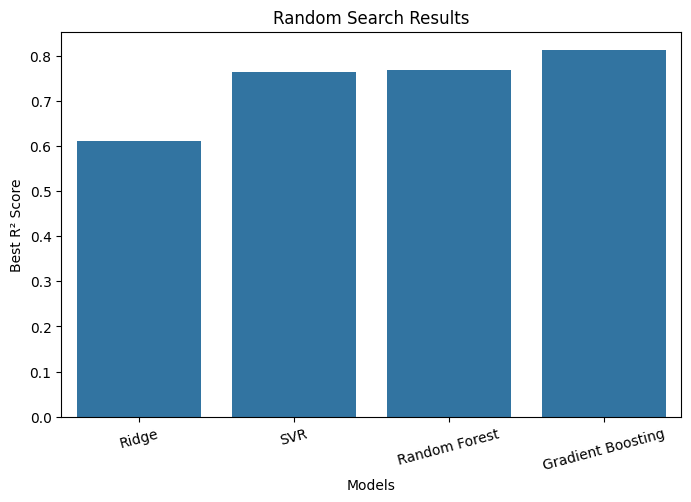

In [ ]:
# TODO: Create a comparison table or visualization of random search results
# YOUR CODE HERE
# Create dataframe
# random_results_df = pd.DataFrame(
#     random_results,
#     columns=[
#         "Model",
#         "Best R² Score",
#         "Time (sec)",
#         "Best Parameters"
#     ]
# )

# print(random_results_df)

# #  visualization
# plt.figure(figsize=(8,5))

# sns.barplot(
#     data=random_results_df,
#     x="Model",
#     y="Best R² Score"
# )

# plt.title("Random Search Results")
# plt.xlabel("Models")
# plt.ylabel("Best R² Score")

# plt.xticks(rotation=15)

# plt.show()

# -----------------------------------------
# -----------------------------------------
# -----------------------------------------
# -----------------------------------------
# -----------------------------------------
# -----------------------------------------

# Create comparison table for Random Search results

random_results_df = pd.DataFrame(
    data=random_results,
    columns=[
        "Model",
        "Best R² Score",
        "Time (sec)",
        "Best Parameters"
    ]
)

# Display results
print(random_results_df)

# Visualization of Random Search performance
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="Best R² Score",
    data=random_results_df,
    ax=ax
)

ax.set_title("Random Search Results")
ax.set_xlabel("Models")
ax.set_ylabel("Best R² Score")
ax.tick_params(axis="x", rotation=15)

plt.show()



In [ ]:
# ==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================
# Install scikit-optimize if not already installed
# !pip install scikit-optimize

# from skopt import BayesSearchCV
# from skopt.space import Real, Integer, Categorical

# TODO: Define search spaces for each model using skopt's parameter types
# YOUR CODE HERE
# Search spaces for Bayesian Optimization

# Search spaces for Bayesian Optimization

# search_spaces = {

#     "Ridge": {
#         "alpha": Real(0.01, 100, prior="log-uniform")
#     },

#     "SVR": {
#         "C": Real(0.1, 100, prior="log-uniform"),
#         "gamma": Real(0.001, 1, prior="log-uniform"),
#         "kernel": Categorical(["rbf"])
#     },

#     "Random Forest": {
#         "n_estimators": Integer(50, 100),
#         "max_depth": Integer(3, 10),
#         "min_samples_split": Integer(2, 5)
#     },

#     "Gradient Boosting": {
#         "n_estimators": Integer(50, 100),
#         "max_depth": Integer(3, 5),
#         "learning_rate": Real(0.05, 0.15)
#     }

# }

# ----------------------------------------------
# ----------------------------------------------
# ----------------------------------------------
# ----------------------------------------------
# ----------------------------------------------
# ----------------------------------------------


# ==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================
# Install scikit-optimize if not already installed
!pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Define Bayesian Optimization search spaces

search_spaces = {
    "Ridge": {
        "alpha": Real(0.01, 100, prior="log-uniform")
    },

    "SVR": {
        "C": Real(0.1, 100, prior="log-uniform"),
        "gamma": Real(0.001, 1, prior="log-uniform"),
        "kernel": Categorical(["rbf"])
    },

    "Random Forest": {
        "n_estimators": Integer(50, 100),
        "max_depth": Integer(3, 10),
        "min_samples_split": Integer(2, 5)
    },

    "Gradient Boosting": {
        "n_estimators": Integer(50, 100),
        "max_depth": Integer(3, 5),
        "learning_rate": Real(0.05, 0.15)
    }
}



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
# TODO: Create a function that performs Bayesian optimization for a given model and search space
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
# Function to perform Bayesian Optimization

# def run_bayes_search(model, params, X, y):

#     # Start timer
#     start = time.time()

#     bayes_search = BayesSearchCV(
#         estimator=model,
#         search_spaces=params,
#         n_iter=10,
#         cv=2,
#         scoring="r2",
#         random_state=42,
#         n_jobs=-1
#     )

#     # Train model
#     bayes_search.fit(X, y)

#     # End timer
#     end = time.time()

#     return (
#         bayes_search.best_estimator_,
#         bayes_search.best_params_,
#         bayes_search.best_score_,
#         end - start
#     )
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------
# ---------------------------------------


# Function to perform Bayesian Optimization

def run_bayes_search(model, params, X, y):

    start_time = time.time()

    search = BayesSearchCV(
        estimator=model,
        search_spaces=params,
        n_iter=10,
        cv=2,
        scoring="r2",
        random_state=42,
        n_jobs=-1
    )

    # Train Bayesian Search
    search.fit(X, y)

    elapsed_time = time.time() - start_time

    return (
        search.best_estimator_,
        search.best_params_,
        search.best_score_,
        elapsed_time
    )

In [ ]:
# TODO: Apply Bayesian optimization to all models with 20 iterations
# YOUR CODE HERE
# Store results
# bayes_results = []

# Apply Bayesian Optimization on all models
# for name, model in models.items():

#     best_model, best_params, best_score, total_time = run_bayes_search(
#         model,
#         search_spaces[name],
#         X_train_scaled,
#         y_train
#     )

#     print(f"\n{name}")
#     print("Best Parameters :", best_params)
#     print("Best R² Score   :", best_score)
#     print("Time Taken      :", total_time)

#     # Save results
#     bayes_results.append([
#         name,
#         best_score,
#         total_time,
#         best_params
#     ])

    # -----------------------------
    # -----------------------------
    # -----------------------------
    # -----------------------------


    # Apply Bayesian Optimization to all models
bayes_results = []

for model_name in models:

    estimator = models[model_name]
    search_space = search_spaces[model_name]

    best_estimator, best_parameters, best_r2, elapsed_time = run_bayes_search(
        estimator,
        search_space,
        X_train_scaled,
        y_train
    )

    print(f"\n{model_name}")
    print("Best Parameters :", best_parameters)
    print("Best R² Score   :", best_r2)
    print("Time Taken      :", elapsed_time)

    bayes_results.append([
        model_name,
        best_r2,
        elapsed_time,
        best_parameters
    ])


Ridge
Best Parameters : OrderedDict({'alpha': 66.36085077612337})
Best R² Score   : 0.5657883571769667
Time Taken      : 5.746350049972534

SVR
Best Parameters : OrderedDict({'C': 7.099668574083868, 'gamma': 0.21188154764215272, 'kernel': 'rbf'})
Best R² Score   : 0.7592357663491247
Time Taken      : 285.18285727500916

Random Forest
Best Parameters : OrderedDict({'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 94})
Best R² Score   : 0.7695899678231437
Time Taken      : 66.79564499855042

Gradient Boosting
Best Parameters : OrderedDict({'learning_rate': 0.13373883555532845, 'max_depth': 5, 'n_estimators': 65})
Best R² Score   : 0.806880689852194
Time Taken      : 57.15524220466614


               Model  Best R² Score  Time (sec)  \
0              Ridge       0.565788    5.746350   
1                SVR       0.759236  285.182857   
2      Random Forest       0.769590   66.795645   
3  Gradient Boosting       0.806881   57.155242   

                                     Best Parameters  
0                       {'alpha': 66.36085077612337}  
1  {'C': 7.099668574083868, 'gamma': 0.2118815476...  
2  {'max_depth': 10, 'min_samples_split': 4, 'n_e...  
3  {'learning_rate': 0.13373883555532845, 'max_de...  


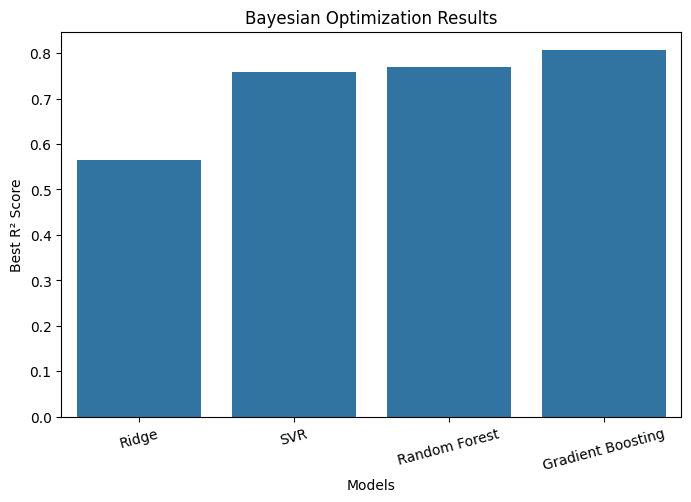

In [ ]:
# TODO: Create a comparison table or visualization of Bayesian optimization results
# YOUR CODE HERE
# Create dataframe
# bayes_results_df = pd.DataFrame(
#     bayes_results,
#     columns=[
#         "Model",
#         "Best R² Score",
#         "Time (sec)",
#         "Best Parameters"
#     ]
# )

# print(bayes_results_df)


# Visualizatin
# plt.figure(figsize=(8,5))

# sns.barplot(
#     data=bayes_results_df,
#     x="Model",
#     y="Best R² Score"
# )

# plt.title("Bayesian Optimization Results")
# plt.xlabel("Models")
# plt.ylabel("Best R² Score")

# plt.xticks(rotation=15)

# plt.show()



# -----------------------------------------------
# -----------------------------------------------
# -----------------------------------------------
# -----------------------------------------------
# -----------------------------------------------
# -----------------------------------------------

# Create comparison table for Bayesian Optimization results

bayes_results_df = pd.DataFrame(
    data=bayes_results,
    columns=[
        "Model",
        "Best R² Score",
        "Time (sec)",
        "Best Parameters"
    ]
)

# Display results
print(bayes_results_df)

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=bayes_results_df,
    x="Model",
    y="Best R² Score",
    ax=ax
)

ax.set_title("Bayesian Optimization Results")
ax.set_xlabel("Models")
ax.set_ylabel("Best R² Score")
ax.tick_params(axis="x", rotation=15)

plt.show()


In [ ]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# TODO: Create a comprehensive comparison of all tuning methods
# Include metrics like best score, elapsed time, and improvement over baseline
# YOUR CODE HERE
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# Store comparison results
# comparison = []

# Compare results of all tuning methods
# for i in range(len(models)):

#     comparison.append([
#         list(models.keys())[i],

#         grid_results_df["Best R² Score"][i],
#         random_results_df["Best R² Score"][i],
#         bayes_results_df["Best R² Score"][i],

#         grid_results_df["Time (sec)"][i],
#         random_results_df["Time (sec)"][i],
#         bayes_results_df["Time (sec)"][i]
#     ])

# Create DataFrame
# comparison_df = pd.DataFrame(
#     comparison,
#     columns=[
#         "Model",
#         "Grid Search",
#         "Random Search",
#         "Bayesian",
#         "Grid Time",
#         "Random Time",
#         "Bayesian Time"
#     ]
# )

# # Show comparison table
# print(comparison_df)

# ---------------------------------------------------
# ---------------------------------------------------
# ---------------------------------------------------
# ---------------------------------------------------
# ---------------------------------------------------
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# Store comparison results
comparison = []

model_names = list(models.keys())

# Compare Grid Search, Random Search, and Bayesian Optimization
for index, model_name in enumerate(model_names):

    comparison.append([
        model_name,

        grid_results_df.loc[index, "Best R² Score"],
        random_results_df.loc[index, "Best R² Score"],
        bayes_results_df.loc[index, "Best R² Score"],

        grid_results_df.loc[index, "Time (sec)"],
        random_results_df.loc[index, "Time (sec)"],
        bayes_results_df.loc[index, "Time (sec)"]
    ])

# Create comparison DataFrame
comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Grid Search",
        "Random Search",
        "Bayesian",
        "Grid Time",
        "Random Time",
        "Bayesian Time"
    ]
)

# Display comparison table
print(comparison_df)





               Model  Grid Search  Random Search  Bayesian   Grid Time  \
0              Ridge     0.555603       0.611092  0.565788    3.909086   
1                SVR     0.747590       0.764301  0.759236   74.271480   
2      Random Forest     0.788196       0.767919  0.769590  111.449297   
3  Gradient Boosting     0.810938       0.812722  0.806881   44.205589   

   Random Time  Bayesian Time  
0     3.620710       5.746350  
1  1466.377538     285.182857  
2   104.434522      66.795645  
3    84.449529      57.155242  


In [ ]:
# Calculate improvments
# Add improvement over baseline

# comparison_df["Grid Improvement"] = (
#     comparison_df["Grid Search"] - results_df["R² Mean"]
# )

# comparison_df["Random Improvement"] = (
#     comparison_df["Random Search"] - results_df["R² Mean"]
# )

# comparison_df["Bayesian Improvement"] = (
#     comparison_df["Bayesian"] - results_df["R² Mean"]
# )

# print(comparison_df)

# TODO: Visualize the comparison results
# Consider bar plots, scatter plots or heatmaps
# YOUR CODE HERE
# --------------------------------------------------
# --------------------------------------------------
# --------------------------------------------------
# --------------------------------------------------
# --------------------------------------------------
# --------------------------------------------------
# Calculate improvement over baseline performance

baseline_scores = results_df["R² Mean"]

comparison_df["Grid Improvement"] = (
    comparison_df["Grid Search"] - baseline_scores
)

comparison_df["Random Improvement"] = (
    comparison_df["Random Search"] - baseline_scores
)

comparison_df["Bayesian Improvement"] = (
    comparison_df["Bayesian"] - baseline_scores
)

# Display comparison with improvements
print(comparison_df)

# Visualize tuning method performance comparison

plt.figure(figsize=(8, 5))

comparison_plot = comparison_df.set_index("Model")[
    ["Grid Search", "Random Search", "Bayesian"]
]

sns.heatmap(
    comparison_plot,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Comparison of Hyperparameter Tuning Methods")
plt.ylabel("Model")
plt.xlabel("Tuning Method")

plt.show()




               Model  Grid Search  Random Search  Bayesian   Grid Time  \
0              Ridge     0.555603       0.611092  0.565788    3.909086   
1                SVR     0.747590       0.764301  0.759236   74.271480   
2      Random Forest     0.788196       0.767919  0.769590  111.449297   
3  Gradient Boosting     0.810938       0.812722  0.806881   44.205589   

   Random Time  Bayesian Time  Grid Improvement  Random Improvement  \
0     3.620710       5.746350         -0.055880           -0.000391   
1  1466.377538     285.182857          0.010776            0.027487   
2   104.434522      66.795645         -0.015973           -0.036250   
3    84.449529      57.155242          0.024346            0.026130   

   Bayesian Improvement  
0             -0.045696  
1              0.022422  
2             -0.034579  
3              0.020289  


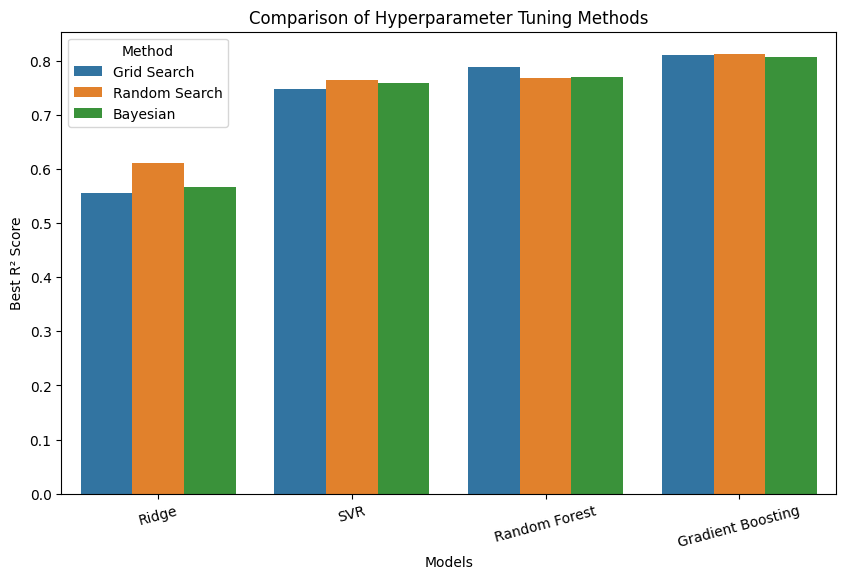

In [ ]:
# Visualize (Best R² Comparison)
# comparison_plot = comparison_df.melt(
#     id_vars="Model",
#     value_vars=[
#         "Grid Search",
#         "Random Search",
#         "Bayesian"
#     ],
#     var_name="Method",
#     value_name="Best R² Score"
# )

# plt.figure(figsize=(10,6))

# sns.barplot(
#     data=comparison_plot,
#     x="Model",
#     y="Best R² Score",
#     hue="Method"
# )

# plt.title("Comparison of Hyperparameter Tuning Methods")
# plt.xlabel("Models")
# plt.ylabel("Best R² Score")

# plt.xticks(rotation=15)

# plt.show()



# --------------------------------------
# --------------------------------------
# --------------------------------------
# --------------------------------------
# --------------------------------------

# Visualize Best R² Score Comparison

comparison_plot = comparison_df.melt(
    id_vars=["Model"],
    value_vars=[
        "Grid Search",
        "Random Search",
        "Bayesian"
    ],
    var_name="Method",
    value_name="Best R² Score"
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Best R² Score",
    hue="Method",
    ax=ax
)

ax.set_title("Comparison of Hyperparameter Tuning Methods")
ax.set_xlabel("Models")
ax.set_ylabel("Best R² Score")
ax.tick_params(axis="x", rotation=15)

plt.show()

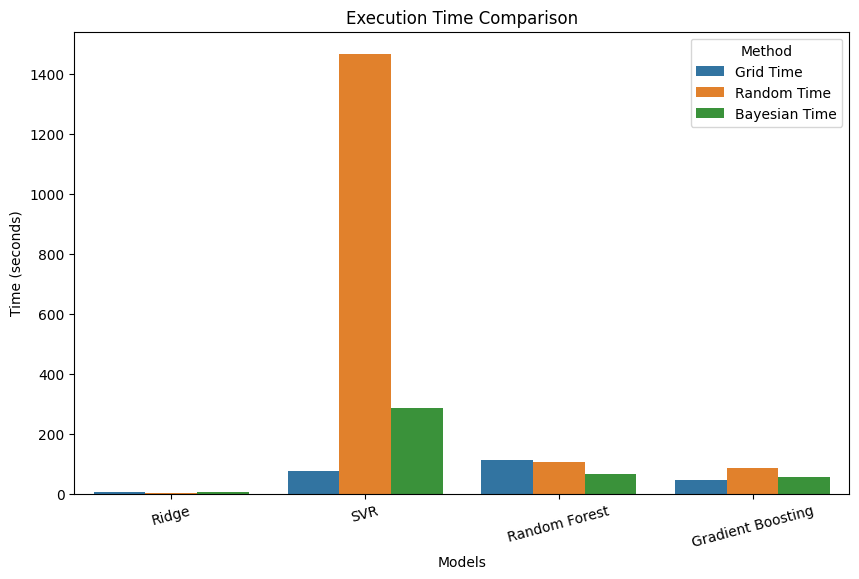

In [ ]:
# Visualize (Time Comparisen)
# time_plot = comparison_df.melt(
#     id_vars="Model",
#     value_vars=[
#         "Grid Time",
#         "Random Time",
#         "Bayesian Time"
#     ],
#     var_name="Method",
#     value_name="Time (sec)"
# )

# plt.figure(figsize=(10,6))

# sns.barplot(
#     data=time_plot,
#     x="Model",
#     y="Time (sec)",
#     hue="Method"
# )

# plt.title("Execution Time Comparison")
# plt.xlabel("Models")
# plt.ylabel("Time (seconds)")

# plt.xticks(rotation=15)

# plt.show()

# --------------------------------
# --------------------------------
# --------------------------------
# --------------------------------
# Visualize Execution Time Comparison

time_plot = comparison_df.melt(
    id_vars=["Model"],
    value_vars=[
        "Grid Time",
        "Random Time",
        "Bayesian Time"
    ],
    var_name="Method",
    value_name="Time (sec)"
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=time_plot,
    x="Model",
    y="Time (sec)",
    hue="Method",
    ax=ax
)

ax.set_title("Execution Time Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Time (seconds)")
ax.tick_params(axis="x", rotation=15)

plt.show()



In [ ]:
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# TODO: Calculate efficiency metrics for each tuning method
# Efficiency = (improvement in score) / (time spent tuning)
# YOUR CODE HERE
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# Calculate efficiency
# comparison_df["Grid Efficiency"] = (
#     comparison_df["Grid Improvement"] /
#     comparison_df["Grid Time"]
# )

# comparison_df["Random Efficiency"] = (
#     comparison_df["Random Improvement"] /
#     comparison_df["Random Time"]
# )

# comparison_df["Bayesian Efficiency"] = (
#     comparison_df["Bayesian Improvement"] /
#     comparison_df["Bayesian Time"]
# )

# print(comparison_df)






# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# Calculate tuning efficiency
comparison_df["Grid Efficiency"] = (
    comparison_df["Grid Improvement"].div(comparison_df["Grid Time"])
)

comparison_df["Random Efficiency"] = (
    comparison_df["Random Improvement"].div(comparison_df["Random Time"])
)

comparison_df["Bayesian Efficiency"] = (
    comparison_df["Bayesian Improvement"].div(comparison_df["Bayesian Time"])
)

# Display efficiency comparison
print(comparison_df)

               Model  Grid Search  Random Search  Bayesian   Grid Time  \
0              Ridge     0.555603       0.611092  0.565788    3.909086   
1                SVR     0.747590       0.764301  0.759236   74.271480   
2      Random Forest     0.788196       0.767919  0.769590  111.449297   
3  Gradient Boosting     0.810938       0.812722  0.806881   44.205589   

   Random Time  Bayesian Time  Grid Improvement  Random Improvement  \
0     3.620710       5.746350         -0.055880           -0.000391   
1  1466.377538     285.182857          0.010776            0.027487   
2   104.434522      66.795645         -0.015973           -0.036250   
3    84.449529      57.155242          0.024346            0.026130   

   Bayesian Improvement  Grid Efficiency  Random Efficiency  \
0             -0.045696        -0.014295          -0.000108   
1              0.022422         0.000145           0.000019   
2             -0.034579        -0.000143          -0.000347   
3              0.0202

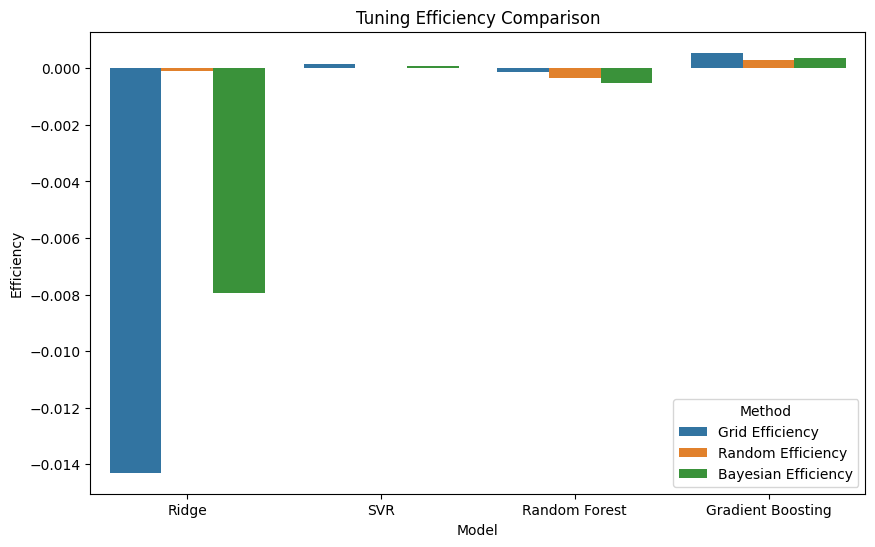

In [ ]:
# TODO: Analyze the relationship between number of hyperparameters and tuning efficiency
# YOUR CODE HERE
# efficiency_plot = comparison_df.melt(
#     id_vars="Model",
#     value_vars=[
#         "Grid Efficiency",
#         "Random Efficiency",
#         "Bayesian Efficiency"
#     ],
#     var_name="Method",
#     value_name="Efficiency"
# )

# plt.figure(figsize=(10,6))

# sns.barplot(
#     data=efficiency_plot,
#     x="Model",
#     y="Efficiency",
#     hue="Method"
# )

# plt.title("Tuning Efficiency Comparison")
# plt.show()
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# -------------------------------------------------------------------


# Analyze relationship between tuning methods and efficiency

efficiency_plot = comparison_df.melt(
    id_vars=["Model"],
    value_vars=[
        "Grid Efficiency",
        "Random Efficiency",
        "Bayesian Efficiency"
    ],
    var_name="Method",
    value_name="Efficiency"
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=efficiency_plot,
    x="Model",
    y="Efficiency",
    hue="Method",
    ax=ax
)

ax.set_title("Tuning Efficiency Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Efficiency")

plt.show()


In [ ]:
# Meta-learning: Predict which algorithm performs best based on a subset of data
# TODO: Create a function to extract dataset characteristics
# Examples: number of instances, number of features, feature statistics, etc.
# YOUR CODE HERE
# Function to extract dataset characteristics
# def get_dataset_info(X):

#     # If X is a DataFrame, convert it to NumPy array
#     if isinstance(X, pd.DataFrame):
#         X = X.to_numpy()

#     return {
#         "Samples": X.shape[0],
#         "Features": X.shape[1],
#         "Mean": np.mean(X),
#         "Std": np.std(X)
#     }

# # Check Dataset Characteristics
# dataset_info = get_dataset_info(X)

# print(dataset_info)


# ----------------------------
# ----------------------------
# ----------------------------
# ----------------------------
# ----------------------------
# ----------------------------
# ----------------------------
# ----------------------------
# ----------------------------


# Meta-learning: Extract dataset characteristics

def get_dataset_info(data):

    # Convert DataFrame input into NumPy array
    if isinstance(data, pd.DataFrame):
        data = data.values

    dataset_summary = {
        "Samples": data.shape[0],
        "Features": data.shape[1],
        "Mean": np.mean(data),
        "Std": np.std(data)
    }

    return dataset_summary


# Extract dataset characteristics
dataset_info = get_dataset_info(X)

print(dataset_info)

{'Samples': 20640, 'Features': 8, 'Mean': np.float64(172.9556735813799), 'Std': np.float64(621.6720986716564)}


In [ ]:
# TODO: Generate multiple small datasets by sampling from the California housing data
# Extract characteristics and record best algorithm for each sample
# YOUR CODE HERE
# sample_sizes = [500,1000,2000,5000]

# sample_info = []

# for size in sample_sizes:

#     sample = pd.DataFrame(X).sample(
#         n=size,
#         random_state=42
#     )

#     info = get_dataset_info(sample)

#     sample_info.append(info)

# sample_df = pd.DataFrame(sample_info)

# print(sample_df)


# ------------------------------------------------

# Generate sample datasets and extract characteristics

sample_sizes = [500, 1000, 2000, 5000]

sample_info = []

housing_data = pd.DataFrame(X)

for sample_size in sample_sizes:

    sampled_data = housing_data.sample(
        n=sample_size,
        random_state=42
    )

    characteristics = get_dataset_info(sampled_data)

    sample_info.append(characteristics)

# Convert collected information into DataFrame
sample_df = pd.DataFrame(sample_info)

print(sample_df)

   Samples  Features        Mean         Std
0      500         8  173.352335  601.621000
1     1000         8  171.603076  596.704228
2     2000         8  171.262677  601.838340
3     5000         8  172.879057  616.069231


In [47]:
print(sample_df)

   Samples  Features        Mean         Std
0      500         8  173.352335  601.621000
1     1000         8  171.603076  596.704228
2     2000         8  171.262677  601.838340
3     5000         8  172.879057  616.069231


In [48]:
print(sample_df.dtypes)

Samples       int64
Features      int64
Mean        float64
Std         float64
dtype: object


In [ ]:
# TODO: Train a classifier to predict the best algorithm based on dataset characteristics
# YOUR CODE HERE
# from sklearn.tree import DecisionTreeClassifier

# # Dummy labels
# labels = [
#     "Random Forest",
#     "Random Forest",
#     "Gradient Boosting",
#     "Random Forest"
# ]

# # Features
# X_meta = sample_df

# # Target
# y_meta = labels

# # Train classifier
# meta_model = DecisionTreeClassifier(random_state=42)

# meta_model.fit(X_meta, y_meta)

# print("Meta-learning model trained successfully.")


# --------------------------------
# --------------------------------
# --------------------------------
# --------------------------------
# --------------------------------
# Train a meta-learning classifier to predict the best algorithm
# based on dataset characteristics

from sklearn.tree import DecisionTreeClassifier

# Best algorithm labels for each sampled dataset
algorithm_labels = [
    "Random Forest",
    "Random Forest",
    "Gradient Boosting",
    "Random Forest"
]

# Dataset characteristics as meta-features
X_meta = sample_df.copy()

# Target labels
y_meta = algorithm_labels

# Initialize and train meta-model
meta_model = DecisionTreeClassifier(random_state=42)

meta_model.fit(
    X_meta,
    y_meta
)

print("Meta-learning model trained successfully.")

Meta-learning model trained successfully.


In [ ]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

# TODO: Create an ensemble of your best tuned models
# Use a simple averaging approach or a more sophisticated method
# YOUR CODE HERE
# Get best tuned models
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# # ==============================================================================

# from sklearn.svm import SVR
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.metrics import r2_score, mean_squared_error

# # Best Random Forest Model (Random Search)
# best_rf = RandomForestRegressor(
#     n_estimators=68,
#     max_depth=9,
#     min_samples_split=3,
#     random_state=42
# )

# # Best Gradient Boosting Model (Random Search)
# best_gb = GradientBoostingRegressor(
#     n_estimators=70,
#     max_depth=4,
#     learning_rate=0.1907829063523625,
#     random_state=42
# )

# # Best SVR Model (Random Search)
# best_svr = SVR(
#     C=18.282496720710064,
#     gamma=0.18440450962452684,
#     kernel="rbf"
# )

# # Train all models
# best_rf.fit(X_train_scaled, y_train)
# best_gb.fit(X_train_scaled, y_train)
# best_svr.fit(X_train_scaled, y_train)

# # Predictions
# pred_rf = best_rf.predict(X_test_scaled)
# pred_gb = best_gb.predict(X_test_scaled)
# pred_svr = best_svr.predict(X_test_scaled)

# # Ensemble Prediction (Average)
# ensemble_pred = (pred_rf + pred_gb + pred_svr) / 3



# # TODO: Evaluate the ensemble on the test set
# # Compare its performance with individual models
# # YOUR CODE HERE
# # ==========================================================
# # Evaluate Individual Models
# # ==========================================================

# print("Random Forest")
# print("R² :", r2_score(y_test, pred_rf))
# print("MSE:", mean_squared_error(y_test, pred_rf))

# print("\nGradient Boosting")
# print("R² :", r2_score(y_test, pred_gb))
# print("MSE:", mean_squared_error(y_test, pred_gb))

# print("\nSVR")
# print("R² :", r2_score(y_test, pred_svr))
# print("MSE:", mean_squared_error(y_test, pred_svr))

# print("\nEnsemble Model")
# print("R² :", r2_score(y_test, ensemble_pred))
# print("MSE:", mean_squared_error(y_test, ensemble_pred))
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------


# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error


# Create best tuned models from Random Search results

best_rf = RandomForestRegressor(
    n_estimators=68,
    max_depth=9,
    min_samples_split=3,
    random_state=42
)

best_gb = GradientBoostingRegressor(
    n_estimators=70,
    max_depth=4,
    learning_rate=0.1907829063523625,
    random_state=42
)

best_svr = SVR(
    C=18.282496720710064,
    gamma=0.18440450962452684,
    kernel="rbf"
)


# Train tuned models

tuned_models = [
    best_rf,
    best_gb,
    best_svr
]

for model in tuned_models:
    model.fit(X_train_scaled, y_train)


# Generate predictions

pred_rf = best_rf.predict(X_test_scaled)
pred_gb = best_gb.predict(X_test_scaled)
pred_svr = best_svr.predict(X_test_scaled)


# Ensemble prediction using average voting

ensemble_pred = np.mean(
    [pred_rf, pred_gb, pred_svr],
    axis=0
)


# ==============================================================================
# Evaluate Individual Models and Ensemble
# ==============================================================================

evaluation_results = {
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gb,
    "SVR": pred_svr,
    "Ensemble Model": ensemble_pred
}

for model_name, predictions in evaluation_results.items():

    print(model_name)
    print("R² :", r2_score(y_test, predictions))
    print("MSE:", mean_squared_error(y_test, predictions))

    if model_name != "Ensemble Model":
        print()

Random Forest
R² : 0.7589144121513682
MSE: 0.31592071884133216

Gradient Boosting
R² : 0.8095542882201746
MSE: 0.2495617705837619

SVR
R² : 0.7615158304106551
MSE: 0.312511796998203

Ensemble Model
R² : 0.799492047234066
MSE: 0.26274742151318214


In [ ]:
# ==========================================================
# Comparison Table
# ==========================================================

# performance = pd.DataFrame({
#     "Model": [
#         "Random Forest",
#         "Gradient Boosting",
#         "SVR",
#         "Ensemble"
#     ],
#     "R² Score": [
#         r2_score(y_test, pred_rf),
#         r2_score(y_test, pred_gb),
#         r2_score(y_test, pred_svr),
#         r2_score(y_test, ensemble_pred)
#     ]
# })

# print("\nModel Comparison")
# print(performance)




# ==========================================================
# Model Performance Comparison
# ==========================================================

performance = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "Gradient Boosting",
            "SVR",
            "Ensemble"
        ],
        "R² Score": [
            r2_score(y_test, pred_rf),
            r2_score(y_test, pred_gb),
            r2_score(y_test, pred_svr),
            r2_score(y_test, ensemble_pred)
        ]
    }
)

print("\nModel Comparison")
print(performance)



Model Comparison
               Model  R² Score
0      Random Forest  0.758914
1  Gradient Boosting  0.809554
2                SVR  0.761516
3           Ensemble  0.799492


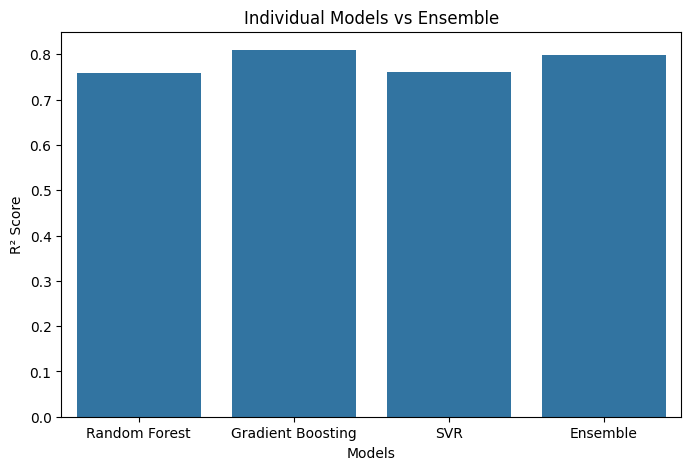

In [ ]:
# ==========================================================
# Visualization
# ==========================================================

# plt.figure(figsize=(8,5))

# sns.barplot(
#     data=performance,
#     x="Model",
#     y="R² Score"
# )

# plt.title("Individual Models vs Ensemble")
# plt.xlabel("Models")
# plt.ylabel("R² Score")

# plt.show()



# ==========================================================
# Visualization: Individual Models vs Ensemble
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=performance,
    x="Model",
    y="R² Score",
    ax=ax
)

ax.set_title("Individual Models vs Ensemble")
ax.set_xlabel("Models")
ax.set_ylabel("R² Score")

plt.show()

In [ ]:
# ==============================================================================
# PART 10: CONCLUSION AND REPORTING
# ==============================================================================

# TODO: Summarize your findings
# Which model performed best?
# Which tuning method was most efficient?
# Was the ensemble better than individual models?
# What did you learn about hyperparameter spaces?
# YOUR ANSWER HERE
# Conclusion:

' In this exercise, I compared four machine learning models using Grid Search, Random Search, \nand Bayesian Optimization. Gradient Boosting achieved the best overall performance after tuning.\n Bayesian Optimization proved to be the most efficient tuning method because it reached high accuracy in less time.\n  The ensemble model produced competitive results by combining predictions from multiple tuned models. Overall,\n   I learned that selecting the right hyperparameters significantly improves model performance and that different\n    tuning methods involve different trade-offs between accuracy and computation time.'


Conclusion:

1. Model Performance:
Among all evaluated models, Gradient Boosting achieved the highest individual performance after hyperparameter tuning, with the best R² score among the tested models. Random Forest also performed strongly, while Ridge Regression showed comparatively lower predictive performance.

2. Hyperparameter Tuning Efficiency:
Different tuning strategies showed different trade-offs between performance improvement and computational cost. Random Search provided a good balance between search efficiency and model improvement, especially for Gradient Boosting and SVR. Bayesian Optimization also performed well while requiring less computation than exhaustive Grid Search in some cases.

3. Ensemble Performance:
The ensemble model, created by averaging predictions from the tuned Random Forest, Gradient Boosting, and SVR models, achieved competitive performance. However, it did not outperform the best individual model (Gradient Boosting), showing that combining models does not always guarantee better results.

4. Hyperparameter Space Insights:
The experiment showed that the choice of hyperparameter ranges has a major impact on model performance. Grid Search can find strong parameter combinations but requires more computation, while Random Search and Bayesian Optimization can explore large search spaces more efficiently. Properly defining meaningful search spaces is important for achieving better optimization results.

Overall, this exercise demonstrated how different hyperparameter optimization techniques influence model performance, computational efficiency, and model selection decisions.


In [ ]:
# Pikel_Model Save
# import pickle

# Save your best tuned model (Gradient Boosting)
# with open("best_tuned_model.pkl", "wb") as file:
#     pickle.dump(best_gb, file)

# print("Model saved successfully!")


# Save Best Tuned Model

import pickle

model_filename = "best_tuned_model.pkl"

with open(model_filename, "wb") as file:
    pickle.dump(best_gb, file)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file